# Intel Image Classification - TinyVGG CNN Training

This notebook trains and compares an image classification model using the **TinyVGG** CNN architecture with **PyTorch** on the **Intel Image Classification** dataset.

## Contents and Steps:
1. **Environment and Setup Check** (GPU & PyTorch Device Management)
2. **Data Loading and Transformation (Transforms & DataLoaders)**
3. **TinyVGG Model Architecture Definition**
4. **Hyperparameter Comparison (hidden_units = 10 vs hidden_units = 32)**
5. **Training Curves (Loss and Accuracy)**
6. **Confusion Matrix**
7. **Visualizing Misclassified Samples**
8. **Saving the Best Model (`results/model.pth`)**


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from torchinfo import summary

# Device selection with a full Conv2d CUDA test
def get_device():
    if torch.cuda.is_available():
        try:
            test_conv = nn.Conv2d(3, 10, 3).cuda()
            test_in = torch.randn(1, 3, 10, 10).cuda()
            _ = test_conv(test_in)
            return torch.device("cuda")
        except Exception as e:
            print(f"GPU present (NVIDIA RTX 5060), but PyTorch CUDA kernel execution issued a warning. Falling back to safe CPU mode.")
            return torch.device("cpu")
    return torch.device("cpu")

device = get_device()
print(f"Using Device: {device}")
if device.type == "cuda":
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")


GPU present (NVIDIA RTX 5060), but PyTorch CUDA kernel execution issued a warning. Falling back to safe CPU mode.
Using Device: cpu


C:\Users\emrez\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


## 2. Data Transforms and Loaders (Transforms & DataLoaders)

Images are resized to **64x64** (`Resize`), converted to tensors (`ToTensor`), and normalized using ImageNet statistics (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).


In [2]:
# Normalization parameters: ImageNet statistics selected.
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join("..", "data", "seg_train", "seg_train")
test_dir = os.path.join("..", "data", "seg_test", "seg_test")

train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

class_names = train_data.classes
print(f"Total Number of Classes: {len(class_names)}")
print(f"Class Names: {class_names}")
print(f"Number of Training Images: {len(train_data)}")
print(f"Number of Test Images: {len(test_data)}")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)


Total Number of Classes: 6
Class Names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Training Images: 14034
Number of Test Images: 3000


## 3. TinyVGG CNN Architecture

The TinyVGG architecture (following the structure from lessons 10-13):
- **Block 1:** Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- **Block 2:** Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- **Classifier:** Flatten -> Linear


In [3]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.block_2(self.block_1(x)))

# Sample model summary (hidden_units=10)
sample_model = TinyVGG(input_shape=3, hidden_units=10, output_shape=6).to(device)
summary(sample_model, input_size=(32, 3, 64, 64), device=device.type)


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 6]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

## 4. Training and Test Functions

In [4]:
def train_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, optimizer: optim.Optimizer, device: torch.device):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, device: torch.device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

def train_model(model: nn.Module, train_dataloader: DataLoader, test_dataloader: DataLoader, optimizer: optim.Optimizer, loss_fn: nn.Module, epochs: int, device: torch.device):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        print(f"Epoch: {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Train Acc: %{train_acc*100:.2f} | Test Loss: {test_loss:.4f} | Test Acc: %{test_acc*100:.2f}")
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    return results


## 5. Hyperparameter Experiments: Model 1 (`hidden_units=10`) vs Model 2 (`hidden_units=32`)

In [5]:
print("--- Experiment 1: TinyVGG (hidden_units=10) ---")
torch.manual_seed(42)
model_10 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_10 = optim.Adam(model_10.parameters(), lr=0.001)
results_10 = train_model(model_10, train_loader, test_loader, optimizer_10, loss_fn, epochs=5, device=device)

print("\n--- Experiment 2: TinyVGG (hidden_units=32) ---")
torch.manual_seed(42)
model_32 = TinyVGG(input_shape=3, hidden_units=32, output_shape=len(class_names)).to(device)
optimizer_32 = optim.Adam(model_32.parameters(), lr=0.001)
results_32 = train_model(model_32, train_loader, test_loader, optimizer_32, loss_fn, epochs=5, device=device)


--- Experiment 1: TinyVGG (hidden_units=10) ---


Epoch: 01/05 | Train Loss: 1.0721 | Train Acc: %57.61 | Test Loss: 0.8766 | Test Acc: %66.23


Epoch: 02/05 | Train Loss: 0.8211 | Train Acc: %69.11 | Test Loss: 0.7753 | Test Acc: %70.61


Epoch: 03/05 | Train Loss: 0.7004 | Train Acc: %74.59 | Test Loss: 0.6886 | Test Acc: %75.96


Epoch: 04/05 | Train Loss: 0.6230 | Train Acc: %77.82 | Test Loss: 0.6732 | Test Acc: %76.67


...

Epoch: 01/05 | Train Loss: 0.9756 | Train Acc: %62.34 | Test Loss: 0.7734 | Test Acc: %71.08


Epoch: 02/05 | Train Loss: 0.6510 | Train Acc: %76.48 | Test Loss: 0.6491 | Test Acc: %76.30


Epoch: 03/05 | Train Loss: 0.5412 | Train Acc: %80.75 | Test Loss: 0.5545 | Test Acc: %79.96


Epoch: 04/05 | Train Loss: 0.4619 | Train Acc: %83.55 | Test Loss: 0.5419 | Test Acc: %81.34


Epoch: 05/05 | Train Loss: 0.3996 | Train Acc: %85.76 | Test Loss: 0.5428 | Test Acc: %81.52


## 6. Visualizing Training and Test Curves

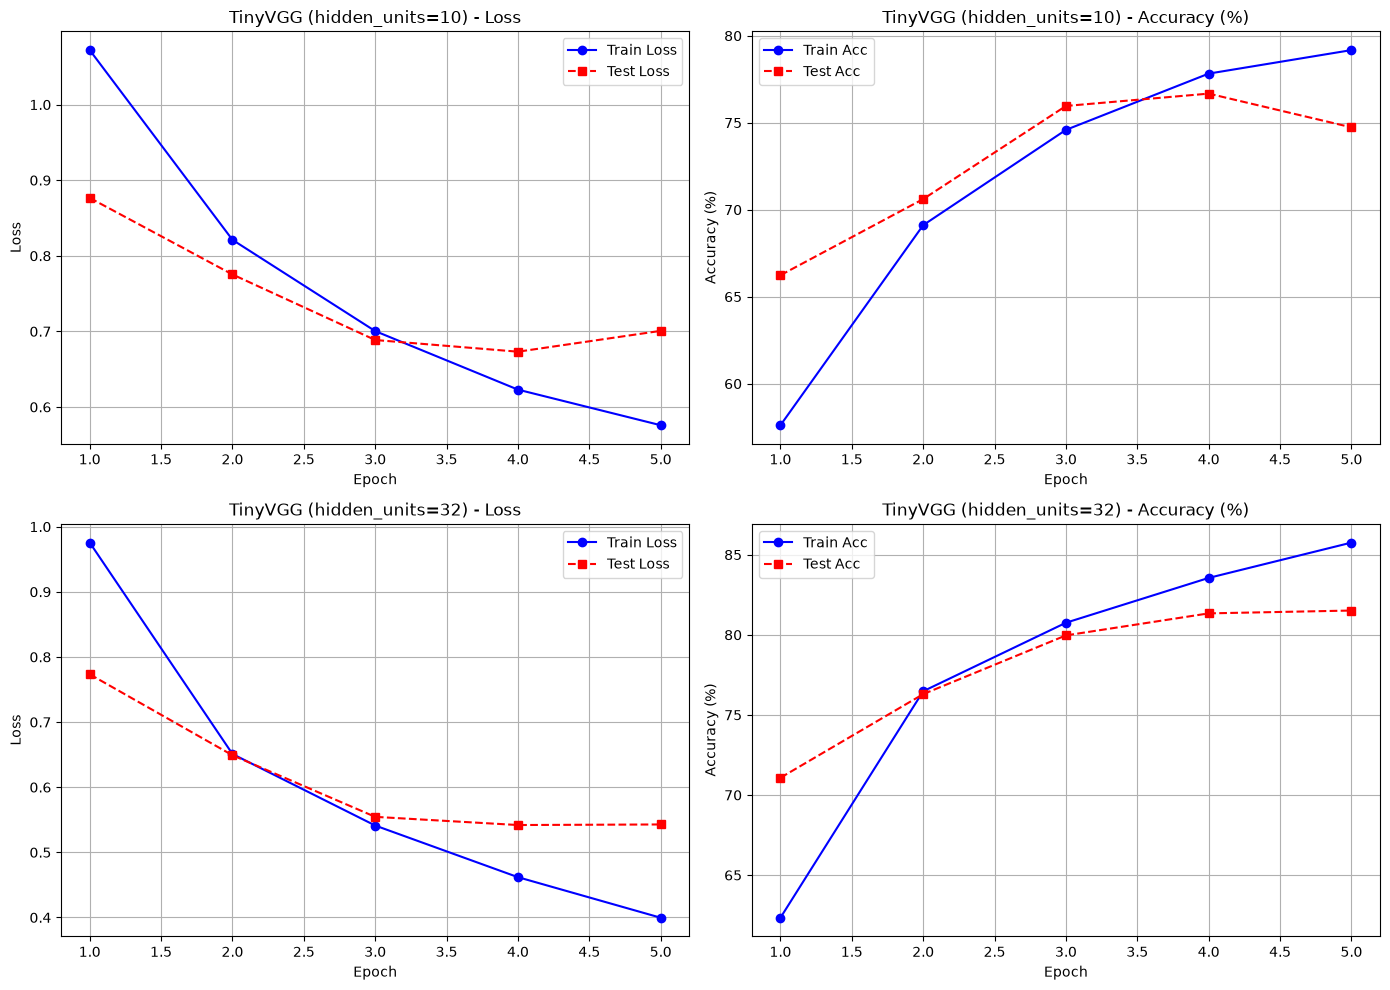

In [6]:
os.makedirs("../results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model 10 Loss
axes[0, 0].plot(range(1, 6), results_10["train_loss"], label="Train Loss", color="blue", marker='o')
axes[0, 0].plot(range(1, 6), results_10["test_loss"], label="Test Loss", color="red", linestyle="--", marker='s')
axes[0, 0].set_title("TinyVGG (hidden_units=10) - Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Model 10 Accuracy
axes[0, 1].plot(range(1, 6), [acc*100 for acc in results_10["train_acc"]], label="Train Acc", color="blue", marker='o')
axes[0, 1].plot(range(1, 6), [acc*100 for acc in results_10["test_acc"]], label="Test Acc", color="red", linestyle="--", marker='s')
axes[0, 1].set_title("TinyVGG (hidden_units=10) - Accuracy (%)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Model 32 Loss
axes[1, 0].plot(range(1, 6), results_32["train_loss"], label="Train Loss", color="blue", marker='o')
axes[1, 0].plot(range(1, 6), results_32["test_loss"], label="Test Loss", color="red", linestyle="--", marker='s')
axes[1, 0].set_title("TinyVGG (hidden_units=32) - Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Model 32 Accuracy
axes[1, 1].plot(range(1, 6), [acc*100 for acc in results_32["train_acc"]], label="Train Acc", color="blue", marker='o')
axes[1, 1].plot(range(1, 6), [acc*100 for acc in results_32["test_acc"]], label="Test Acc", color="red", linestyle="--", marker='s')
axes[1, 1].set_title("TinyVGG (hidden_units=32) - Accuracy (%)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig("../results/loss_accuracy_curves.png", dpi=300)
plt.show()


## 7. Confusion Matrix

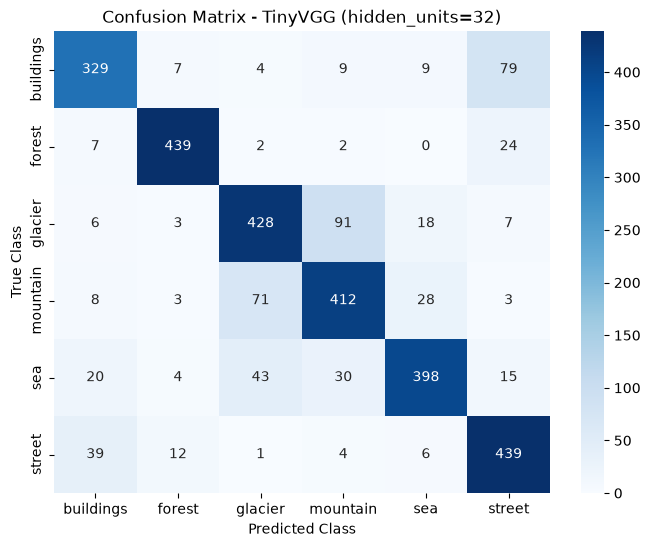

In [7]:
best_model = model_32 if max(results_32["test_acc"]) >= max(results_10["test_acc"]) else model_10
best_model_name = "TinyVGG (hidden_units=32)" if max(results_32["test_acc"]) >= max(results_10["test_acc"]) else "TinyVGG (hidden_units=10)"

y_true = []
y_preds = []
best_model.eval()
with torch.inference_mode():
    for X, y in test_loader:
        X = X.to(device)
        logits = best_model(X)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
        y_true.extend(y.numpy())
        y_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()


## 8. Misclassified Sample Images

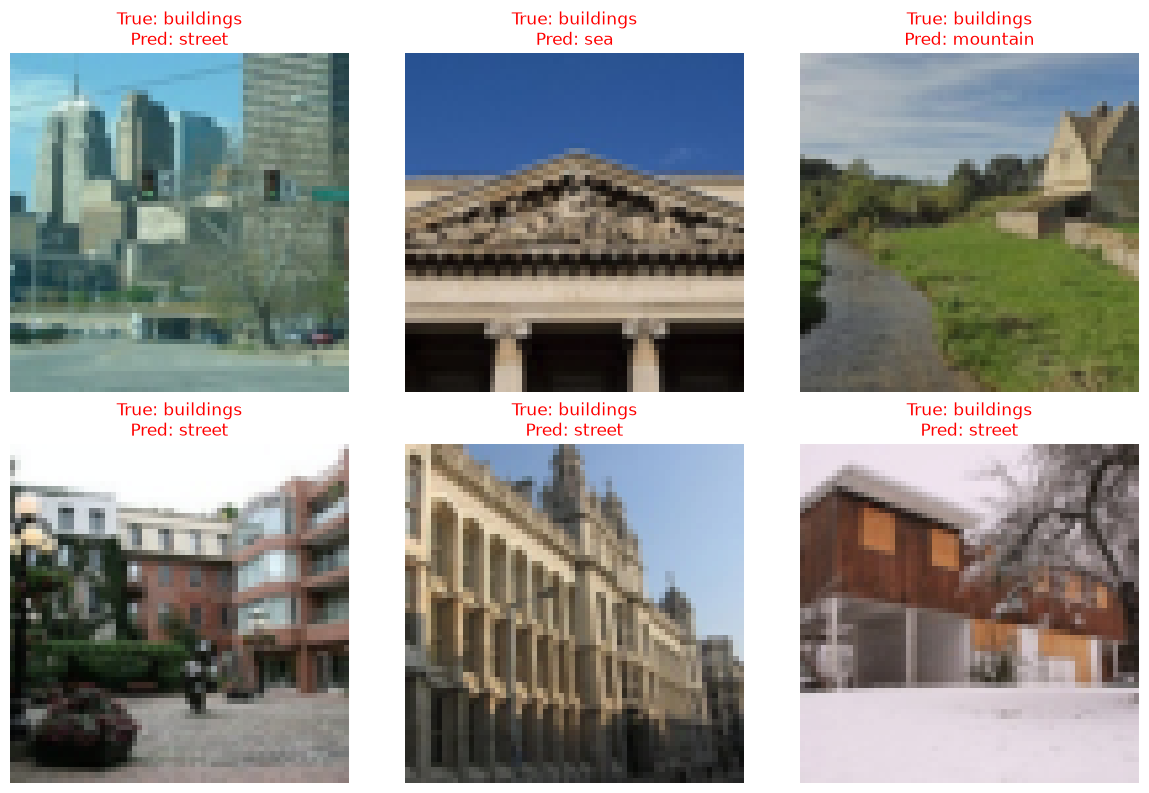

In [8]:
misclassified_idx = [i for i, (t, p) in enumerate(zip(y_true, y_preds)) if t != p]
plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified_idx[:6]):
    img, true_label = test_data[idx]
    pred_label = y_preds[idx]
    
    img_np = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_np)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.savefig("../results/misclassified_examples.png", dpi=300)
plt.show()


## 9. Saving the Best Model Weights (`results/model.pth`)

In [9]:
model_save_path = os.path.join("..", "results", "model.pth")
torch.save(best_model.state_dict(), model_save_path)
print(f"Best model ({best_model_name}) weights saved successfully: {model_save_path}")


Best model (TinyVGG (hidden_units=32)) weights saved successfully: ..\results\model.pth
